In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn import preprocessing
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.naive_bayes import GaussianNB
from astroML.classification import GMMBayes
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
from sklearn.model_selection import KFold


%config InlineBackend.figure_format='retina'
plt.rc('text', usetex=True)

### Time to get your hands dirty. SDSS Galaxies vs quasars

We're now going to classify galaxy vs quasars in the Sloan Digital Sky Survey. 


#### Data

The dataset is at `solutions/galaxyquasar.csv`. I have extracted it myself from the SDSS database using the SQL query reported [here](https://www.astroml.org/_modules/astroML/datasets/sdss_galaxy_colors.html#fetch_sdss_galaxy_colors)

(If you've never used [SQL](https://en.wikipedia.org/wiki/SQL) and want to learn something new in computing, it's very powerful)

#### Tasks

- Create arrays for the $(u-g)$, $(g-r)$, $(r-i)$, and $(i-z)$ colors. Also create an array with the class labels where galaxy=$0$ and quasar=$1$. 
- Classify the dataset against the target label.
- Try some of the classification methods we've seen so far and evaluate the performance using the ROC curve.
- Remember to split the dataset into training and validation...

#### Ideas
- Try using different colors (a subset of them first, than all together). Which is the most important feature?
- What are the colors that better satisfy or invalidate the "Naive" assumption of independence between the attributes?


In [2]:
df = pd.read_csv('../solutions/galaxyquasar.csv')

In [3]:
df

,u,g,r,i,z,class,z1,zerr
0,18.97213,18.53676,18.58280,18.34936,18.29215,QSO,0.522819,0.000155
1,19.24592,17.47646,16.47817,16.04472,15.68851,GALAXY,0.122846,0.000028
2,19.43536,17.70268,16.91565,16.58327,16.39128,GALAXY,0.000000,0.000000
3,19.31626,18.18312,17.39591,16.94549,16.65395,GALAXY,0.147435,0.000009
4,19.28828,19.11188,18.88937,18.80013,18.49183,QSO,2.011455,0.000631
...,...,...,...,...,...,...,...,...
49995,19.37295,18.12382,17.39886,16.98503,16.70585,GALAXY,0.113016,0.000011
49996,18.52021,16.88262,16.03280,15.56884,15.22454,GALAXY,0.085063,0.000014
49997,18.62718,17.30876,16.87371,16.62399,16.42296,GALAXY,0.054429,0.000008
49998,19.55140,18.27711,17.62101,17.21947,17.03347,GALAXY,0.112571,0.000009


In [4]:
ug = np.array(df['u']-df['g'])
gr = np.array(df['g']-df['r'])
ri = np.array(df['r']-df['i'])
iz = np.array(df['i']-df['z'])

colors = [ug,gr,ri,iz]
cl = np.array(df['class'])

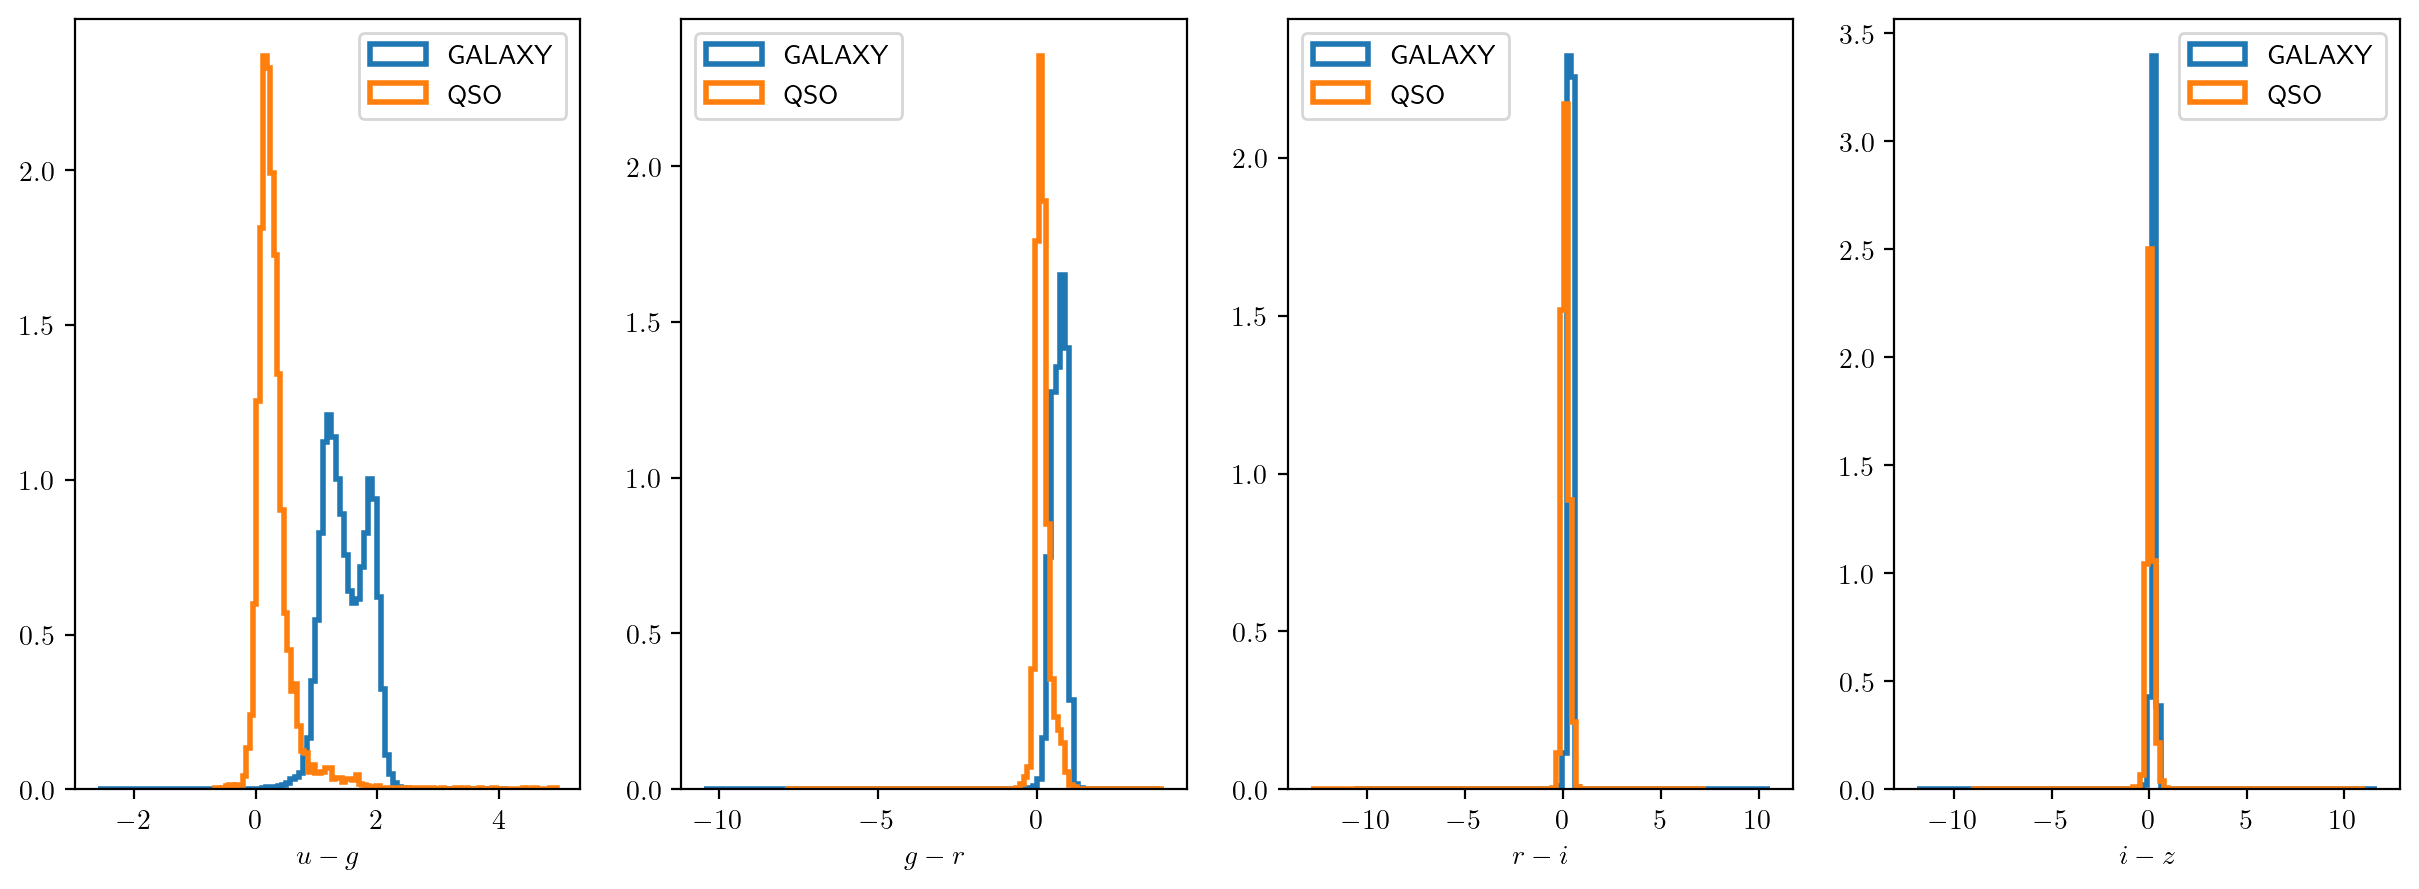

In [5]:
fig, ax = plt.subplots(1,4, figsize = [15,5])
cnames = ['$u-g$', '$g-r$', '$r-i$', '$i-z$']
for i in range(4):
    ax[i].hist(colors[i][cl == 'GALAXY'], bins = 100, density = True, label = 'GALAXY', histtype = 'step', lw = 2)
    ax[i].hist(colors[i][cl == 'QSO'], bins = 100, density = True, label = 'QSO', histtype = 'step', lw = 2)
    ax[i].set_xlabel(cnames[i])
    ax[i].legend()


In [6]:
le = preprocessing.LabelEncoder()
# Assign unique integers from 0 to 6 to each star type
df['class'] = le.fit_transform(df['class'])
labels = le.inverse_transform(df['class'])
class_names = le.classes_
print(class_names)

['GALAXY' 'QSO']


In [7]:
y = df['class'].to_numpy()
print(np.sum(y))

7134


u-g
AUC ROC 0.9760621047623654
g-r
AUC ROC 0.9345029273213561
r-i
AUC ROC 0.8842568330975222
i-z
AUC ROC 0.8389865615927463


Text(0, 0.5, 'True positive rate')

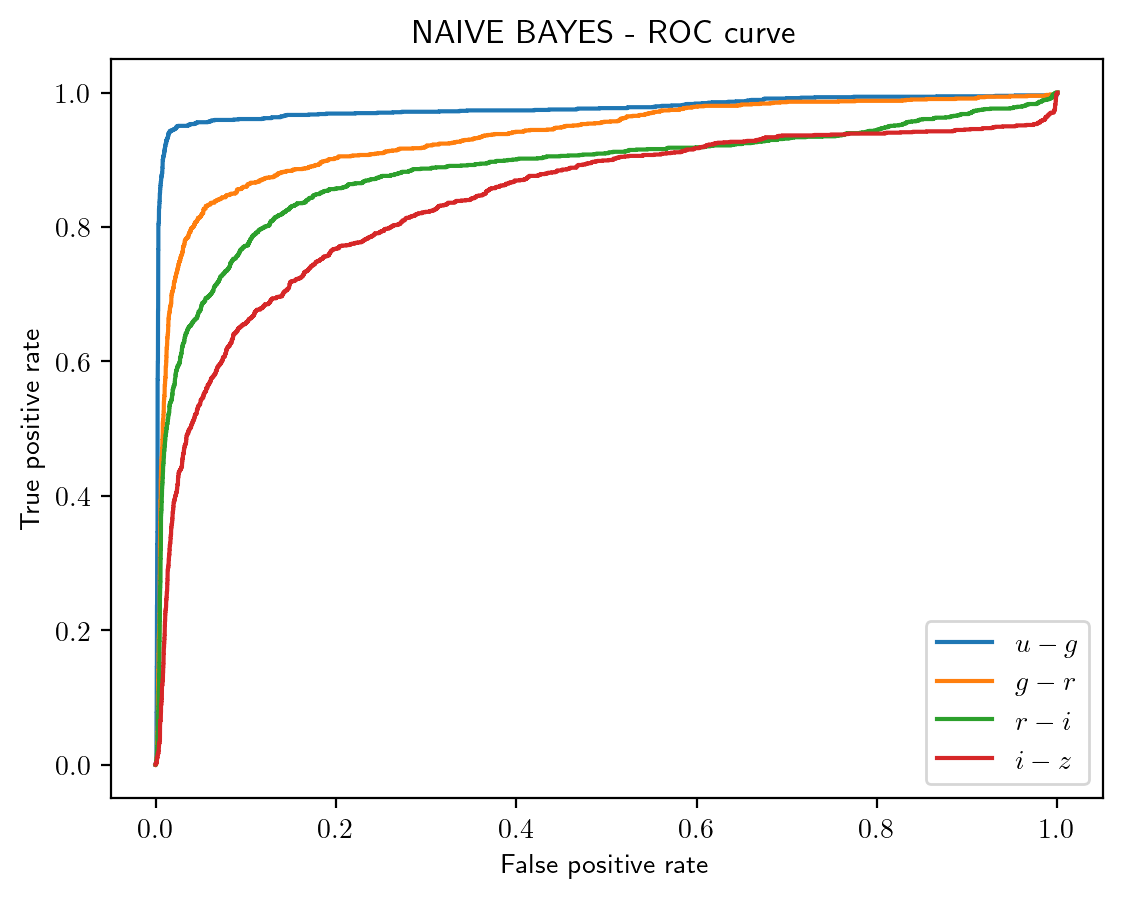

In [8]:
# NAIVE BAYES : assuming all features are independent
cns = ['u-g', 'g-r', 'r-i', 'i-z']

for i in range(4):
    print(cns[i])
    X = (colors[i])[:,np.newaxis]
    y = df['class']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
    gnb = GaussianNB()
    gnb_fit = gnb.fit(X_train, y_train)
    y_prob = gnb_fit.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    print('AUC ROC', roc_auc_score(y_test, y_prob))
    plt.plot(fpr, tpr, label = cnames[i])

plt.legend()
plt.title('NAIVE BAYES - ROC curve')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')

In [9]:
def kfold_cv(Xtrain, ytrain, model):

    kf = KFold(n_splits=5, shuffle=True)

    eps_cv = []
    eps_tr = []

    for train, val in kf.split(Xtrain):

        Xval = Xtrain[val]
        yval = ytrain[val]

        Xtr = Xtrain[train]
        ytr = ytrain[train]

        model.fit(Xtr, ytr)
        ypred_tr = model.predict_proba(Xtr)[:,1]
        ypred_val = model.predict_proba(Xval)[:,1]

        eps_tr.append(roc_auc_score(y_true=ytr, y_score=ypred_tr))
        eps_cv.append(roc_auc_score(y_true=yval, y_score=ypred_val))

    return np.mean(eps_tr), np.mean(eps_cv)

In [10]:
X = np.array(colors).T
scaler = preprocessing.StandardScaler() # working column-wise
scaler.fit(X)
X = scaler.transform(X)
y = df['class'].to_numpy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

Text(0.5, 1.0, 'GMM Bayes')

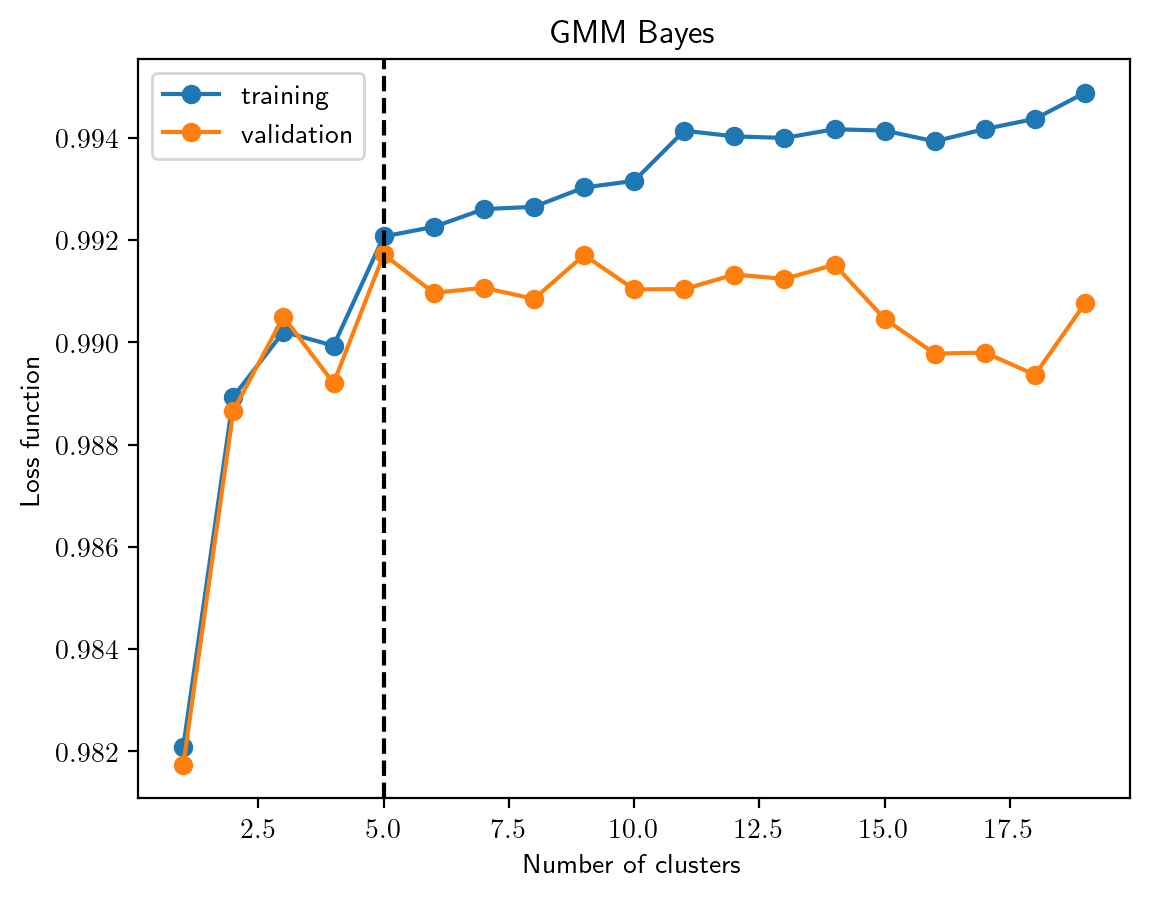

In [11]:
# GAUSSIAN MIXTURE MODEL BAYES

tr_loss = []
cv_loss = [] 
n_values = np.arange(1,20)

for n in n_values: # clusters per class

    tr_l, cv_l = kfold_cv(X_train, y_train, model = GMMBayes(n))
    tr_loss.append(tr_l)
    cv_loss.append(cv_l)

plt.plot(n_values, tr_loss, label = 'training', marker = 'o')
plt.plot(n_values, cv_loss, label = 'validation', marker = 'o')
plt.xlabel('Number of clusters')
plt.ylabel('Loss function')
plt.legend()
plt.axvline(n_values[np.argmax(cv_loss)], c = 'black', ls = '--')
plt.title('GMM Bayes')


AUC ROC 0.96
confusion matrix
[[8333  190]
 [  99 1378]]
completeness: 0.93 contamination: 0.12


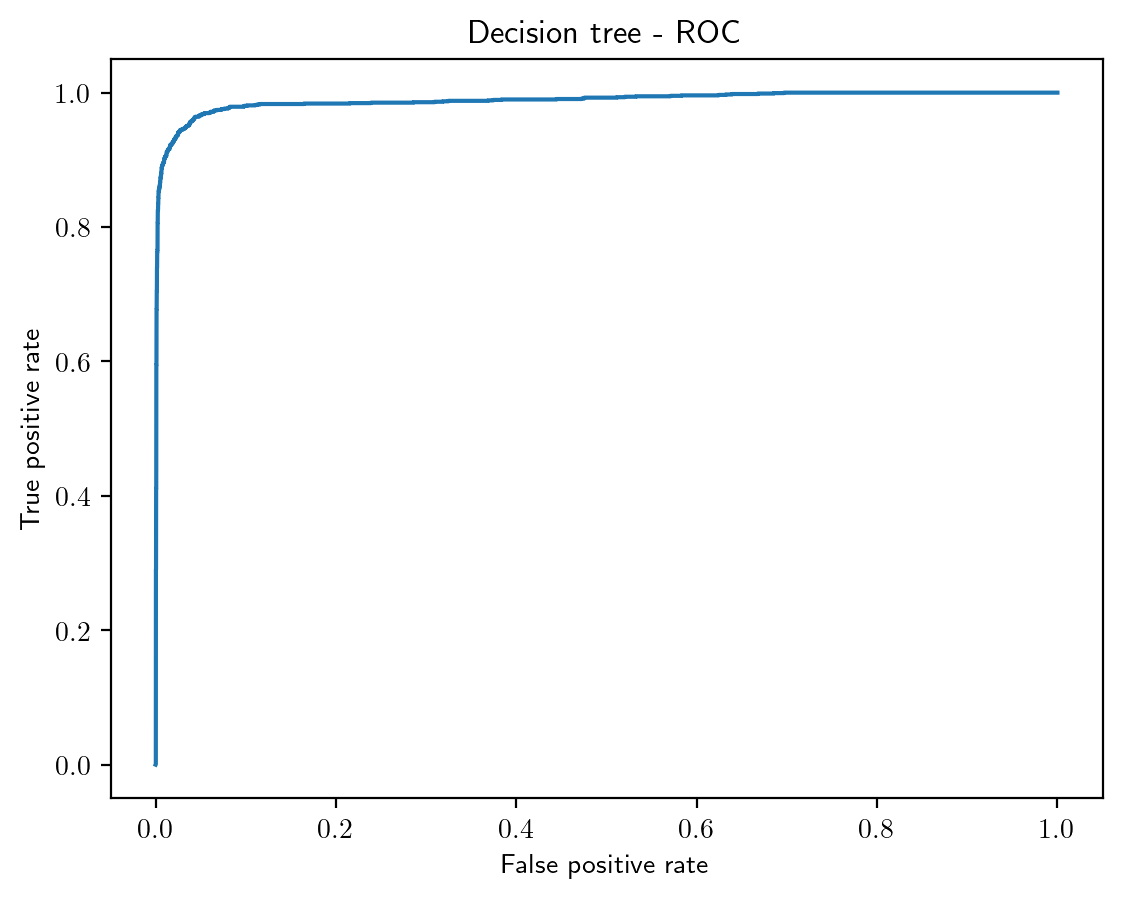

In [12]:
best_n = np.argmax(cv_loss)
clf = GMMBayes(best_n)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.title('Decision tree - ROC')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')

CM = (confusion_matrix(y_test, y_pred))
print(f'AUC ROC {roc_auc_score(y_true=y_test, y_score=y_pred):.2f}')
print('confusion matrix')
print(CM)
tn, fp, fn, tp = CM.ravel()
completeness = (tp/(tp+fn))
contamination = (fp/(tp+fp))
print(f'completeness: {completeness:.2f}', f'contamination: {contamination:.2f}')

Text(0.5, 1.0, 'kNN - Loss')

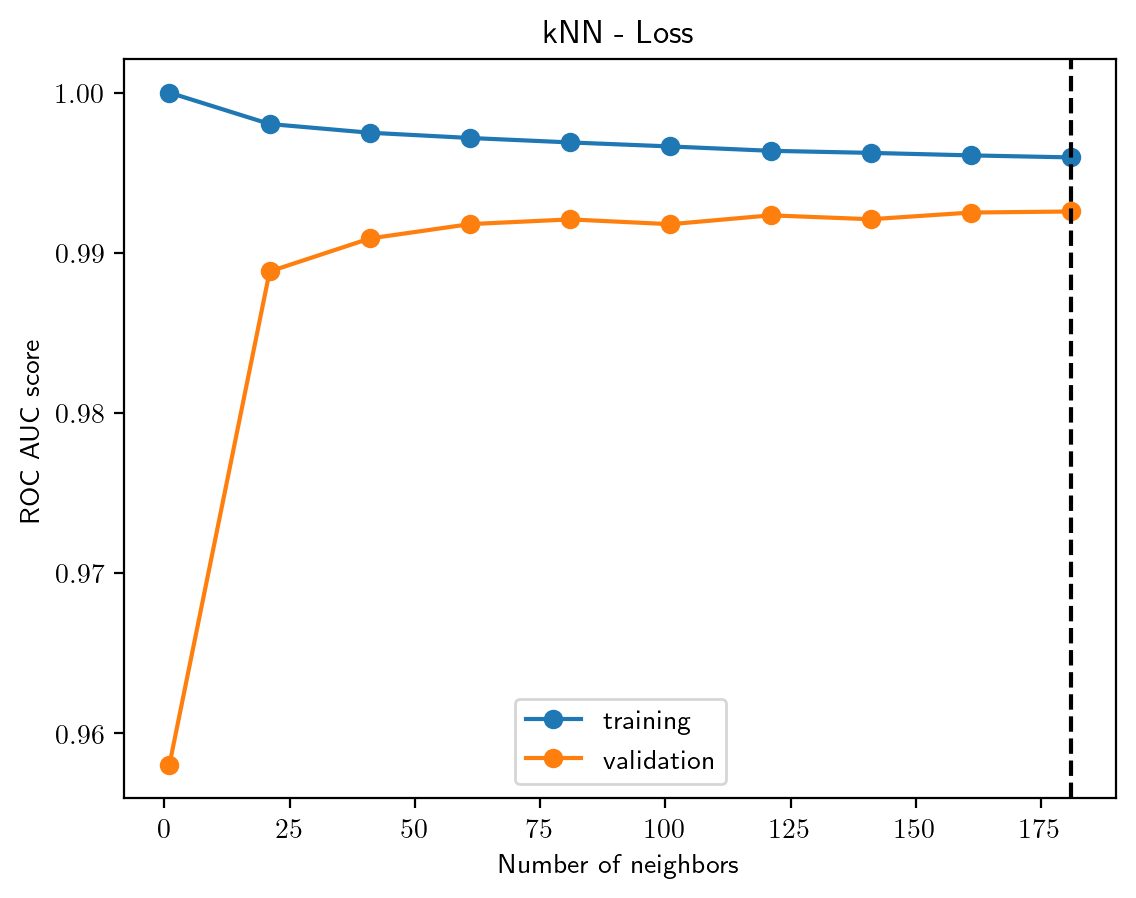

In [13]:
# kNN CLASSIFIER

tr_loss = []
cv_loss = [] 
k_neighbors = np.arange(1,200)[::20]

for k in k_neighbors: # clusters per class

    tr_l, cv_l = kfold_cv(X_train, y_train, model = KNeighborsClassifier(k))
    tr_loss.append(tr_l)
    cv_loss.append(cv_l)

plt.plot(k_neighbors, tr_loss, label = 'training', marker = 'o')
plt.plot(k_neighbors, cv_loss, label = 'validation', marker = 'o')
plt.xlabel('Number of neighbors')
plt.ylabel('ROC AUC score')
plt.legend()
plt.axvline(k_neighbors[np.argmax(cv_loss)], c = 'black', ls = '--')
plt.title('kNN - Loss')


AUC ROC 0.96
confusion matrix
[[8439   84]
 [ 112 1365]]
completeness: 0.92 contamination: 0.06


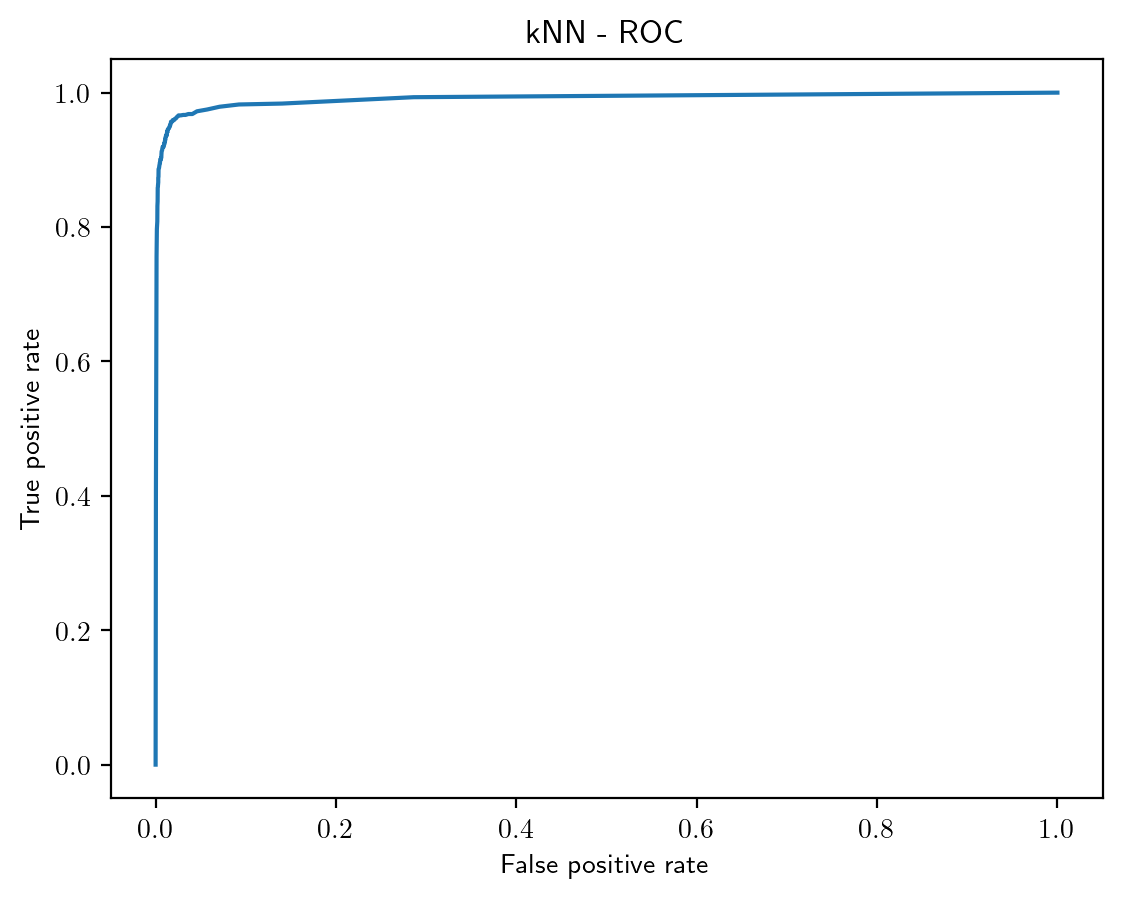

In [14]:
best_k = k_neighbors[np.argmax(cv_loss)]
clf = KNeighborsClassifier(best_k)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.title('kNN - ROC')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')

CM = (confusion_matrix(y_test, y_pred))
print(f'AUC ROC {roc_auc_score(y_true=y_test, y_score=y_pred):.2f}')
print('confusion matrix')
print(CM)
tn, fp, fn, tp = CM.ravel()
completeness = (tp/(tp+fn))
contamination = (fp/(tp+fp))
print(f'completeness: {completeness:.2f}', f'contamination: {contamination:.2f}')